### GITHUB LINK: https://github.com/PRASHIRAWAL/ML-LAB-PROBLEM-STATEMENT-

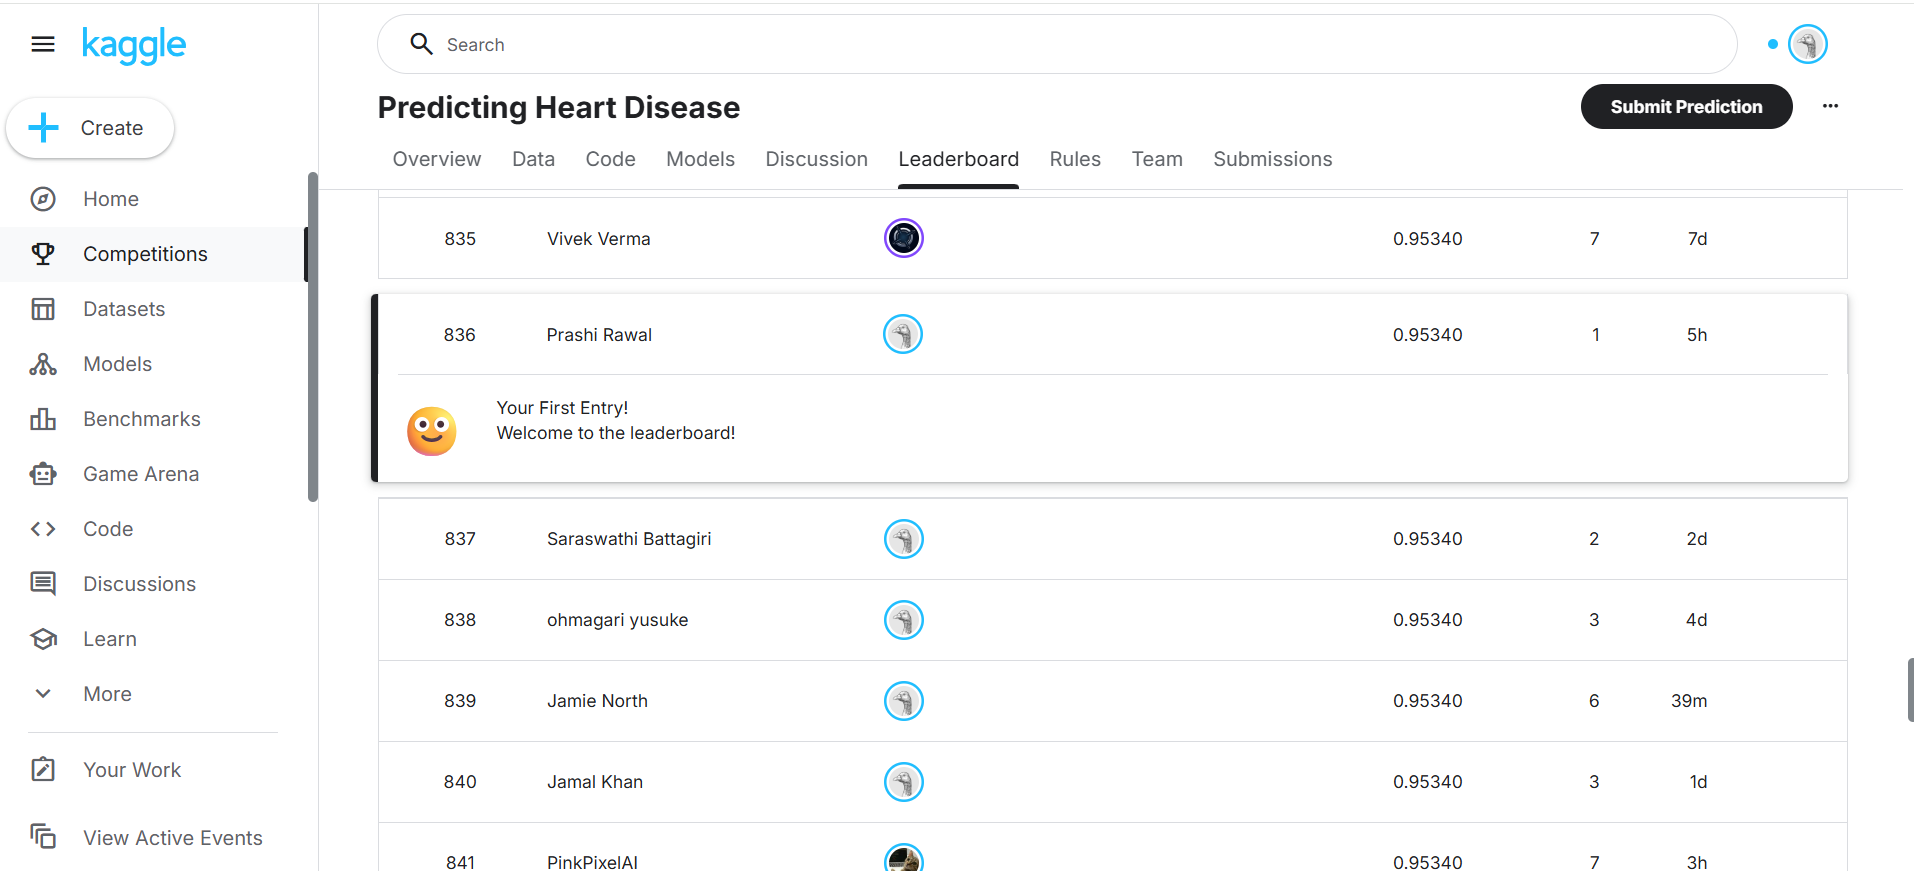

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s6e2_path = kagglehub.competition_download('playground-series-s6e2')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e2/sample_submission.csv
/kaggle/input/playground-series-s6e2/train.csv
/kaggle/input/playground-series-s6e2/test.csv


In [ ]:
sample = pd.read_csv('/kaggle/input/playground-series-s6e2/sample_submission.csv')
train = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')

print(train.shape)
print(test.shape)

(630000, 15)
(270000, 14)


In [ ]:
df = train
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


<Axes: >

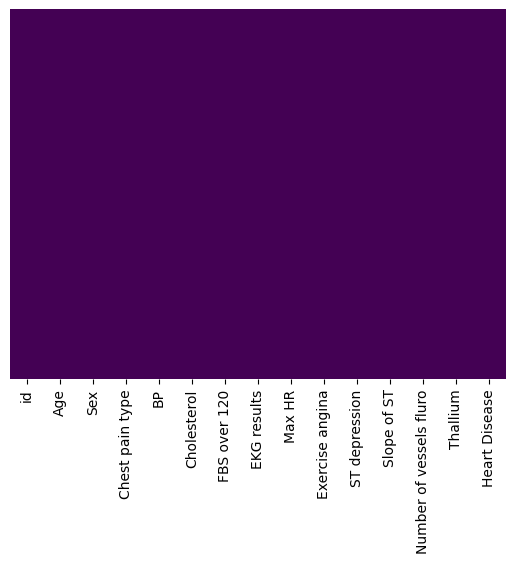

In [ ]:
print(df.isnull().sum())
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [ ]:
def feature_eng(data):
    data['Age_Group'] = pd.cut(data['Age'], bins=[0, 40, 55, 70, 100], labels=[0, 1, 2, 3]).astype(int)
    data['Cholesterol_Risk'] = (data['Cholesterol'] > 240).astype(int)
    data['BP_Risk'] = (data['BP'] > 140).astype(int)
    return data
df=feature_eng(df)

Text(0.5, 1.0, 'Target Distribution')

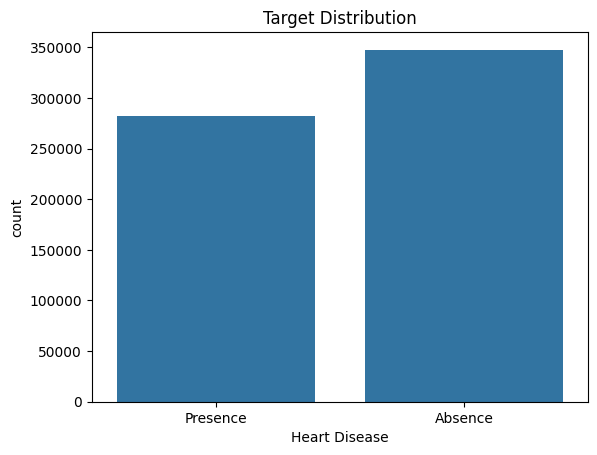

In [ ]:
sns.countplot(x='Heart Disease',data=train)
plt.title("Target Distribution")

Text(0.5, 1.0, 'Age Distribution by Heart Disease')

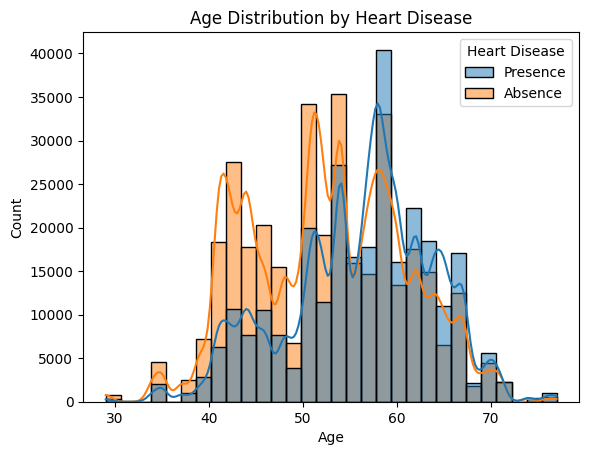

In [ ]:
sns.histplot(data=train,x="Age", hue='Heart Disease',bins=30,kde=True)
plt.title("Age Distribution by Heart Disease")

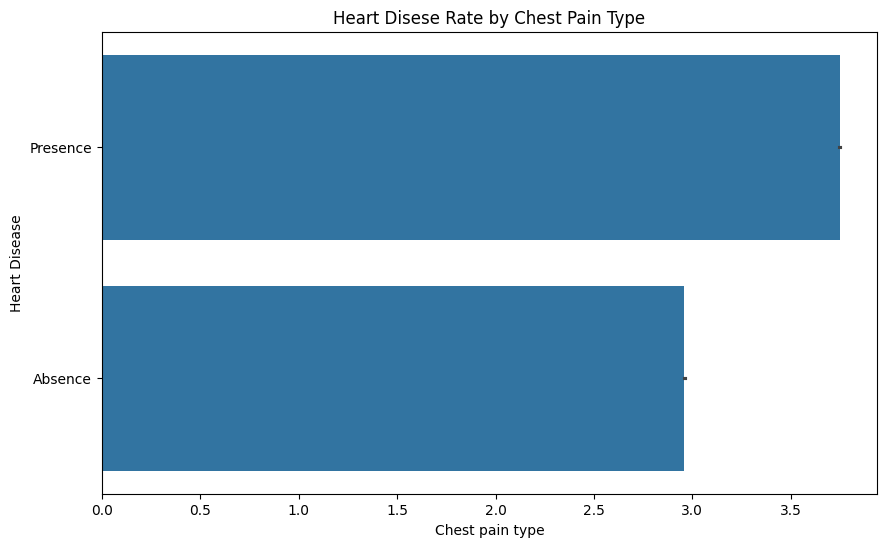

In [ ]:
# Chest pain type vs Heart Diesese
plt.figure(figsize=(10,6))
sns.barplot(x='Chest pain type', y='Heart Disease' , data=train)
plt.title("Heart Disese Rate by Chest Pain Type")
plt.show()

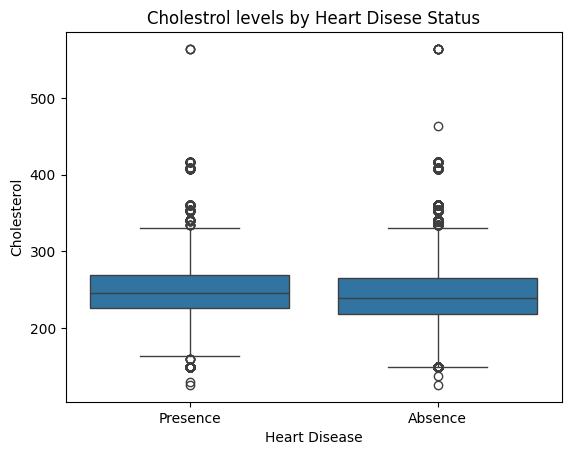

In [ ]:
# Cholestrol levels for sick vs Healty patients
sns.boxplot(x="Heart Disease",y= "Cholesterol",data= train)
plt.title("Cholestrol levels by Heart Disese Status")
plt.show()

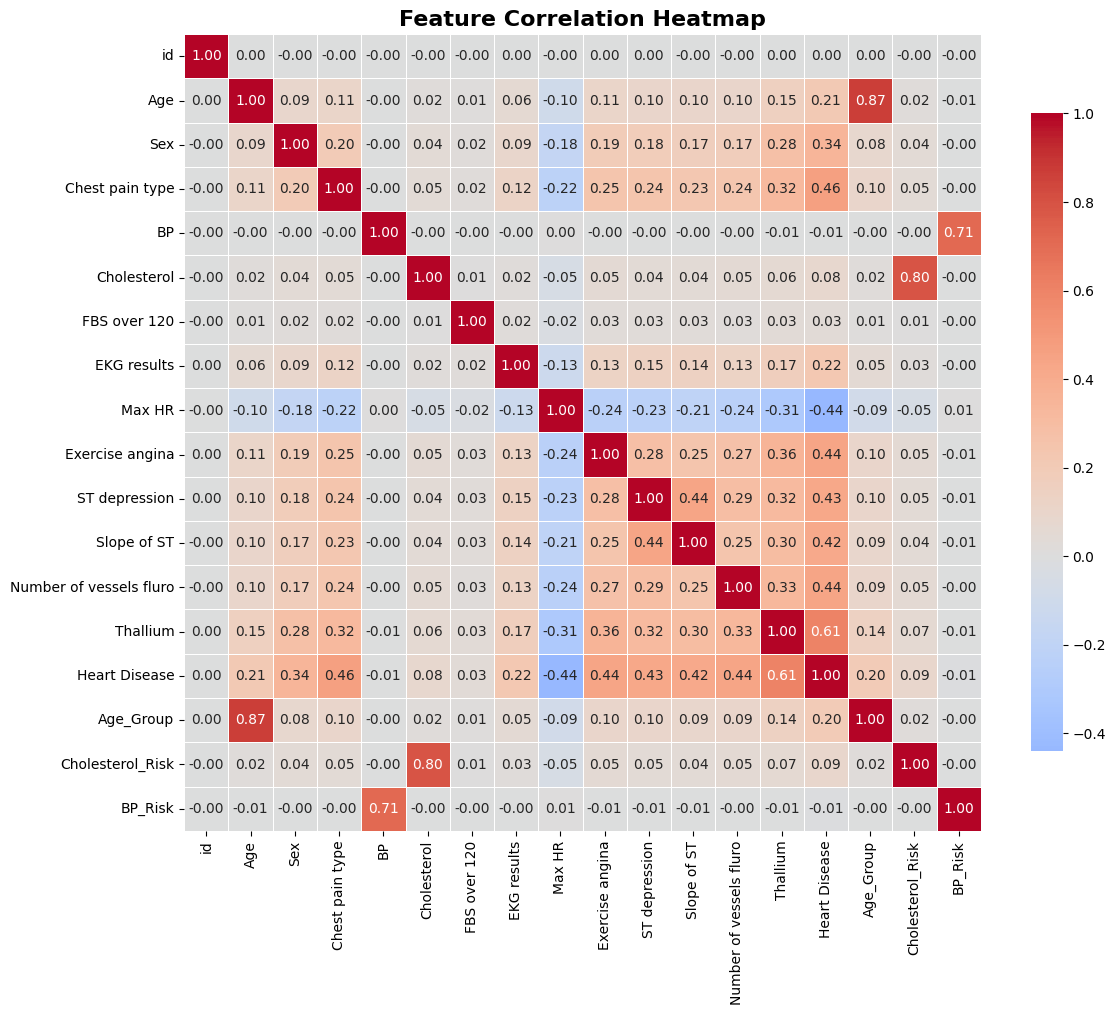

In [ ]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Presence': 1,
    'Absence': 0
})

plt.figure(figsize=(12, 10))


correlation_matrix = train.corr()

# Create the heatmap
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(['Heart Disease','id'],axis=1)
y = df['Heart Disease']



X_train, X_val , y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(504000, 16)
(504000,)
(126000, 16)
(126000,)


In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 758,
    'learning_rate':  0.1921,
    'max_depth': 2,
    'reg_lambda': 3.678,
    'subsample': 0.776,
    'colsample_bytree': 0.775,
    'grow_policy': 'depthwise',
    'tree_method': 'auto',
    'enable_categorical': True,
    'early_stopping_rounds': 10
}
xgb_model = XGBClassifier(
    **xgb_params,
    verbosity=0,
    random_state=42
)
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)] ,
    verbose=False
)
xgb_pred = xgb_model.predict(X_val)

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
y_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, y_probs)
print(f"ROC AUC Score for XGB: {xgb_auc:.4f}")

ROC AUC Score for XGB: 0.9552


Text(0.5, 1.0, 'Top 10 Importance Features')

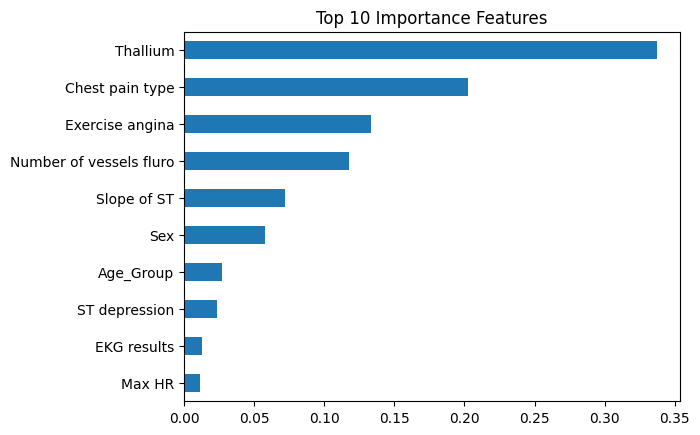

In [ ]:
feature_imp = pd.Series(xgb_model.feature_importances_, index = X.columns)
feature_imp.sort_values().tail(10).plot(kind='barh')
plt.title("Top 10 Importance Features")

In [ ]:
test_df = test.drop(['id'],axis=1)
test_df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

In [ ]:
test_df=feature_eng(test_df)
test_pred = xgb_model.predict_proba(test_df)[:,1]
sample['Heart Disease'] = test_pred
sample.to_csv('submission.csv',index=False)
sample.head()

,id,Heart Disease
0,630000,0.931261
1,630001,0.006828
2,630002,0.989728
3,630003,0.003627
4,630004,0.218362
